In [133]:
# %load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.data_qc import *

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29"

session_index = build_sessions_index(data_dir)

In [135]:
session_index

session_id,x_um,y_um,date_yyyymmdd,time_hhmm,total_captured_sweeps,saved_sweeps,sweeps_per_block,samples_per_block,csv_path,meta_path,timestamp,notes,fs_hz,block_timing_csv,force_available,x_force_available,z_force_available,total_force_samples,calibration_offset_x,calibration_offset_z,force_note,timing_csv
str,null,null,str,str,i64,i64,i64,i64,str,str,str,str,f64,object,bool,bool,bool,i64,f64,f64,str,object
"""adc_data_20260129_1742""",null,null,"""20260129""","""1742""",65534,65534,2,10,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-01-29 17:42:13""",null,null,/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260129_1741_block_timing.csv,false,false,false,0,0.0,0.0,"""Force data not available""",/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260129_1741_block_timing.csv
"""adc_data_20260129_1744""",null,null,"""20260129""","""1744""",7510,7510,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-01-29 17:44:42""",null,1424.501425,/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260129_1744_block_timing.csv,false,false,false,0,0.0,0.0,"""Force data not available""",/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260129_1744_block_timing.csv
"""adc_data_20260203_1208""",null,null,"""20260203""","""1208""",29183,29183,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-02-03 12:08:12""","""20s""",1426.533524,/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1207_block_timing.csv,false,false,false,0,0.0,0.0,"""Force data not available""",/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1207_block_timing.csv
"""adc_data_20260203_1210""",null,null,"""20260203""","""1210""",21503,21503,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-02-03 12:10:09""","""15s""",1424.501425,/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1209_block_timing.csv,false,false,false,0,0.0,0.0,"""Force data not available""",/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1209_block_timing.csv
"""adc_data_20260203_1211""",null,null,"""20260203""","""1211""",7679,7679,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-02-03 12:11:22""","""5s""",1424.501425,/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1211_block_timing.csv,false,false,false,0,0.0,0.0,"""Force data not available""",/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1211_block_timing.csv


<Axes: xlabel='session_id', ylabel='gap'>

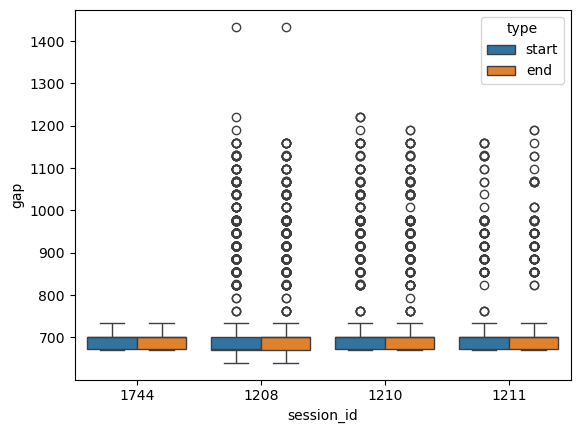

In [115]:
query = (pl.col("sweeps_per_block") == 1)
valid_sessions = session_index.filter(query)

truncate_row = 5
gap_df = {"gap":[], "type": [], "session_id": []}

for row in valid_sessions.iter_rows(named=True):
    timing_csv = pd.read_csv(row["timing_csv"], index_col=0)
    n_samples = 0
    for suff in ["start", "end"]:
        gaps = timing_csv[f"block_{suff}_us"].to_numpy()
        gaps = gaps[truncate_row:]
        gaps = np.diff(gaps)
        gap_df[f"gap"].extend(gaps.tolist())
        gap_df["type"].extend([suff] * len(gaps))
        gap_df["session_id"].extend([row["session_id"].split("_")[-1]] * len(gaps))

sns.boxplot(data=pd.DataFrame(gap_df), x="session_id", y="gap", hue="type")

In [116]:
time_csv_path = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/adc_debug_01_29/adc_data_20260203_1211_block_timing.csv"
timing_csv = pd.read_csv(time_csv_path, index_col=0)
gaps = np.diff(timing_csv["block_end_us"].to_numpy())
fs_hz, median_gap = get_approx_sampling_rate(gaps, truncate=5)

In [118]:
drop_out, ratio = get_dropout_idx(gaps, median_gap, threshold_r=1.8)
print(drop_out)
print("Dropout ratio:", ratio)

[0]
Dropout ratio: 0.00013024225058609013


In [120]:
for row in valid_sessions.iter_rows(named=True):
    timing_csv = pd.read_csv(row["timing_csv"], index_col=0)
    samples_per_block = row["samples_per_block"]
    gaps = np.diff(timing_csv["block_end_us"].to_numpy())

    appox_fs, median_gap = get_approx_sampling_rate(gaps, truncate=5)
    print(row["session_id"], appox_fs)
    sweeps = row["saved_sweeps"] 
    duration_s = sweeps / appox_fs
    print("Approximate duration (manual):", row["notes"], 
          "duration by sampling rate:", duration_s, "\n")

adc_data_20260129_1744 1424.5014245014245
Approximate duration (manual): None duration by sampling rate: 5.27202 

adc_data_20260203_1208 1426.5335235378031
Approximate duration (manual): 20s duration by sampling rate: 20.457283 

adc_data_20260203_1210 1424.5014245014245
Approximate duration (manual): 15s duration by sampling rate: 15.095106 

adc_data_20260203_1211 1424.5014245014245
Approximate duration (manual): 5s duration by sampling rate: 5.390658 

